# Top-Hat Log-Normal Test (Constant $E_{iso}$, distributed $\theta_c$)

This notebook is a **BNS-only** test (no NSBH) with:

1. `z_model = 'fiducial_Hrad_A1.0'`
2. Log-normal distribution for event-by-event $\theta_c$
3. Constant-$E_{iso}$ luminosity scaling per event:

$$L_{\mathrm{app},i} \propto 1-\cos(\theta_{c,i}).$$

Because $\theta_c$ is sampled from a distribution, this naturally produces a **variety of apparent luminosities**.

In [26]:
%load_ext autoreload
%autoreload 2

import notebook_setup
import src.init
import emcee
import corner
import numpy as np
import matplotlib.pyplot as plt
from math import inf
from pathlib import Path

from src.top_hat.montecarlo import (
    create_k_interpolator,
    create_log_probability_function,
    luminosity_gen,
    compute_luminosity_distance,
    apply_detection_cuts,
    score_func_cvm,
    poiss_log,
    run_mcmc,
    check_and_resume_mcmc,
)
from src.top_hat.geometric_eff import create_geometric_efficiency_lognormal_interpolator

plt.style.use('../configurations/style.mplstyle')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# Global setup
datafiles = Path('../datafiles')
N_WALKERS = 20
N_STEPS = 30_000
N_PARAMS = 6
PARAM_NAMES = ['A_index', 'L_L0', 'L_mu_E', 'sigma_E', 'theta_c_med', 'f_j']
MAX_FJ = 10.0
SIGMA_THETA_C = 0.5
THETA_MIN = 1.0
THETA_MAX = 45.0

In [28]:
def sample_theta_c_lognormal_truncated(theta_c_med, size, rng, sigma_theta_c=SIGMA_THETA_C, theta_min=THETA_MIN, theta_max=THETA_MAX):
    """Sample theta_c from a truncated log-normal distribution in degrees."""
    mu = np.log(theta_c_med)
    sigma = sigma_theta_c * np.log(10)

    theta = rng.lognormal(mean=mu, sigma=sigma, size=size)
    invalid = (theta < theta_min) | (theta > theta_max)

    while np.any(invalid):
        theta[invalid] = rng.lognormal(mean=mu, sigma=sigma, size=np.sum(invalid))
        invalid = (theta < theta_min) | (theta > theta_max)

    return theta


def simplified_montecarlo_lognormal_constant_eiso(thetas, n_events, params_in, distances, k_interpolator, rng=None):
    A_index, L_L0, L_mu_E_10, sigma_E_10, theta_c_med, fj = thetas

    if rng is None:
        rng = params_in.rng

    # Sample event-by-event theta_c from the log-normal distribution.
    theta_c_samples = sample_theta_c_lognormal_truncated(theta_c_med, n_events, rng)
    lum_factor = 1.0 - np.cos(np.deg2rad(theta_c_samples))

    l_10 = np.log(10)
    L_base_iso = luminosity_gen(A_index, n_events, rng=rng) * 10 ** (L_L0 + 49)
    L_obs_iso = L_base_iso * lum_factor

    E_p_rest = rng.lognormal(mean=L_mu_E_10 * l_10, sigma=sigma_E_10 * l_10, size=n_events)

    id_z = rng.integers(low=0, high=len(params_in.z_arr), size=n_events)
    z_arr = params_in.z_arr[id_z]
    d_L_sq = distances[id_z] ** 2
    E_p_obs = E_p_rest / (1 + z_arr)

    k_corr = k_interpolator.ev(np.log10(E_p_obs), z_arr)
    p_flux = L_obs_iso / (4 * np.pi * d_L_sq * k_corr) * 6.242e8

    return {
        'p_flux': p_flux,
        'E_p_obs': E_p_obs,
        'z_arr': z_arr,
        'L_base_iso': L_base_iso,
        'L_obs_iso': L_obs_iso,
        'theta_c_samples': theta_c_samples,
        'lum_factor': lum_factor,
    }


geom_eff_interp = create_geometric_efficiency_lognormal_interpolator(
    sigma_theta_c=SIGMA_THETA_C,
    minimum_theta_c=THETA_MIN,
    maximum_theta_c=25.0,
)


def log_prior_lognormal_constant_eiso(thetas):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_med, fj = thetas

    if not (1.5 < A_index < 12):
        return -inf
    if not (-2 < L_L0 < 7):
        return -inf
    if not (0.1 < L_mu_E < 7):
        return -inf
    if not (0 < sigma_E < 2.5):
        return -inf
    if not (1.0 < theta_c_med < 25.0):
        return -inf
    if not (0 < fj < MAX_FJ):
        return -inf

    return 0.0


def log_likelihood_lognormal_constant_eiso(thetas, params_in, distances, k_interpolator, n_events=10_000):
    theta_c_med, fj = thetas[4], thetas[5]

    gbm_eff = 0.6
    geometric_efficiency = float(geom_eff_interp(theta_c_med))
    epsilon = geometric_efficiency * fj

    expected_events = epsilon * len(params_in.z_arr) * gbm_eff * params_in.triggered_years
    if expected_events <= 0:
        return -inf, -inf, -inf, -inf, -inf

    results = simplified_montecarlo_lognormal_constant_eiso(
        thetas, n_events, params_in, distances, k_interpolator
    )

    trigger_mask, analysis_mask = apply_detection_cuts(results['p_flux'], results['E_p_obs'])
    if np.sum(analysis_mask) <= 3:
        return -inf, -inf, -inf, -inf, -inf

    physics_efficiency = np.sum(trigger_mask) / n_events
    predicted_detections = expected_events * physics_efficiency
    observed_detections = params_in.yearly_rate * params_in.triggered_years

    l1 = score_func_cvm(results['p_flux'][analysis_mask], params_in.pflux_data, params_in.rng)
    l2 = score_func_cvm(results['E_p_obs'][analysis_mask], params_in.epeak_data, params_in.rng)
    l3 = poiss_log(k=observed_detections, mu=predicted_detections)

    return l1 + l2 + l3, l1, l2, l3, physics_efficiency


def initialize_walkers_lognormal_constant_eiso(n_walkers):
    np.random.seed(42)
    return np.column_stack([
        np.random.uniform(2, 3, n_walkers),
        np.random.uniform(2, 4.0, n_walkers),
        np.random.uniform(2.0, 4.0, n_walkers),
        np.random.uniform(0.2, 1.0, n_walkers),
        np.random.uniform(4.0, 10.0, n_walkers),
        np.random.uniform(0.4, 1.5, n_walkers),
    ])

In [29]:
# Simulation setup (requested z model)
params = {
    'alpha': -0.67,
    'beta_s': -2.59,
    'n': 2,
    'theta_v_max': 10, # doesn't matter
    'theta_c' : 3.4, # doesn't matter
    'z_model': 'fiducial_Hrad_A1.0',
}

default_params, _, _ = src.init.initialize_simulation(datafiles, params=params)
k_interpolator = create_k_interpolator()

log_prob = create_log_probability_function(
    log_prior_func=log_prior_lognormal_constant_eiso,
    log_likelihood_func=log_likelihood_lognormal_constant_eiso,
    params_in=default_params,
    k_interpolator=k_interpolator,
)

print(f'Catalogue events: {len(default_params.pflux_data)}')
print(f'Yearly rate: {default_params.yearly_rate:.2f} GRBs/yr')

Using redshift model: samples_fiducial_Hrad_A1.0_BNSs_0.dat with 359079 BNSs.
Computed total merger rate: 360832.5 yr^-1 (local R_0 = 112.0 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Catalogue events: 268
Yearly rate: 18.58 GRBs/yr


theta_c sample summary [deg]: [ 1.51138049  6.92872096 31.06926961]
luminosity scaling summary: [0.00034789 0.007303   0.143456  ]
log10(L_base_iso) summary: [51.96739413 52.29794746 52.9955524 ]
log10(L_obs_iso)  summary: [48.82353408 50.22149073 51.60545798]


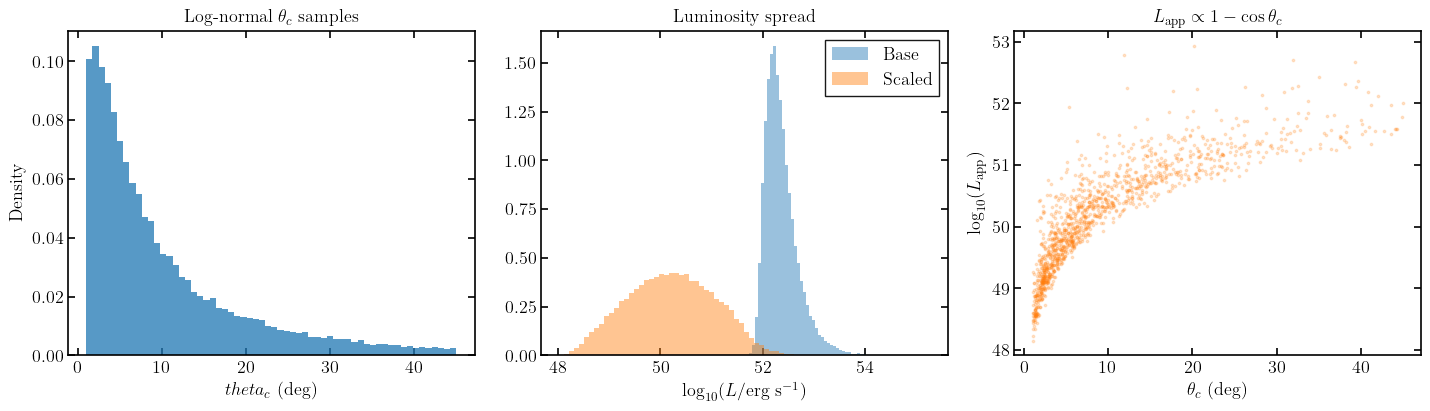

In [30]:
# Diagnostic: show that theta_c distribution creates luminosity variety
theta_test = np.array([2.5, 3.1, 2.9, 0.5, 7.0, 1.0])
distances = compute_luminosity_distance(default_params.z_arr)

demo = simplified_montecarlo_lognormal_constant_eiso(
    theta_test,
    n_events=50_000,
    params_in=default_params,
    distances=distances,
    k_interpolator=k_interpolator,
    rng=np.random.default_rng(123),
)

print('theta_c sample summary [deg]:', np.percentile(demo['theta_c_samples'], [5, 50, 95]))
print('luminosity scaling summary:', np.percentile(demo['lum_factor'], [5, 50, 95]))
print('log10(L_base_iso) summary:', np.percentile(np.log10(demo['L_base_iso']), [5, 50, 95]))
print('log10(L_obs_iso)  summary:', np.percentile(np.log10(demo['L_obs_iso']), [5, 50, 95]))

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3))

axes[0].hist(demo['theta_c_samples'], bins=60, alpha=0.75, color='C0', density=True)
axes[0].set_xlabel(r'$\\theta_c$ (deg)')
axes[0].set_ylabel('Density')
axes[0].set_title(r'Log-normal $\theta_c$ samples')

axes[1].hist(np.log10(demo['L_base_iso']), bins=60, alpha=0.45, label='Base', density=True)
axes[1].hist(np.log10(demo['L_obs_iso']), bins=60, alpha=0.45, label='Scaled', density=True)
axes[1].set_xlabel(r'$\log_{10}(L/\mathrm{erg\ s^{-1}})$')
axes[1].set_title('Luminosity spread')
axes[1].legend()

axes[2].scatter(demo['theta_c_samples'][::40], np.log10(demo['L_obs_iso'][::40]), s=3, alpha=0.2, color='C1')
axes[2].set_xlabel(r'$\theta_c$ (deg)')
axes[2].set_ylabel(r'$\log_{10}(L_{\mathrm{app}})$')
axes[2].set_title(r'$L_{\mathrm{app}} \propto 1-\cos\theta_c$')

plt.tight_layout()
plt.show()

In [31]:
# Run or resume MCMC
output_dir = src.init.create_run_dir('Paper_Results/TopHat_LN_thetaDist_constantEiso', use_timestamp=False)
filename = output_dir / 'emcee.h5'

initial_pos, n_steps_to_do, backend = check_and_resume_mcmc(
    filename=filename,
    n_steps=N_STEPS,
    initialize_walkers_func=initialize_walkers_lognormal_constant_eiso,
    n_walkers=N_WALKERS,
)

if n_steps_to_do > 0:
    sampler = run_mcmc(
        log_probability_func=log_prob,
        initial_walkers=initial_pos,
        n_iterations=n_steps_to_do,
        n_walkers=N_WALKERS,
        n_params=N_PARAMS,
        backend=backend,
    )
else:
    print('Run already complete at target steps.')

Loading existing directory  : Output_files/Paper_Results/TopHat_LN_thetaDist_constantEiso
Continuing from iteration 20000


100%|██████████| 10000/10000 [11:12<00:00, 14.87it/s]


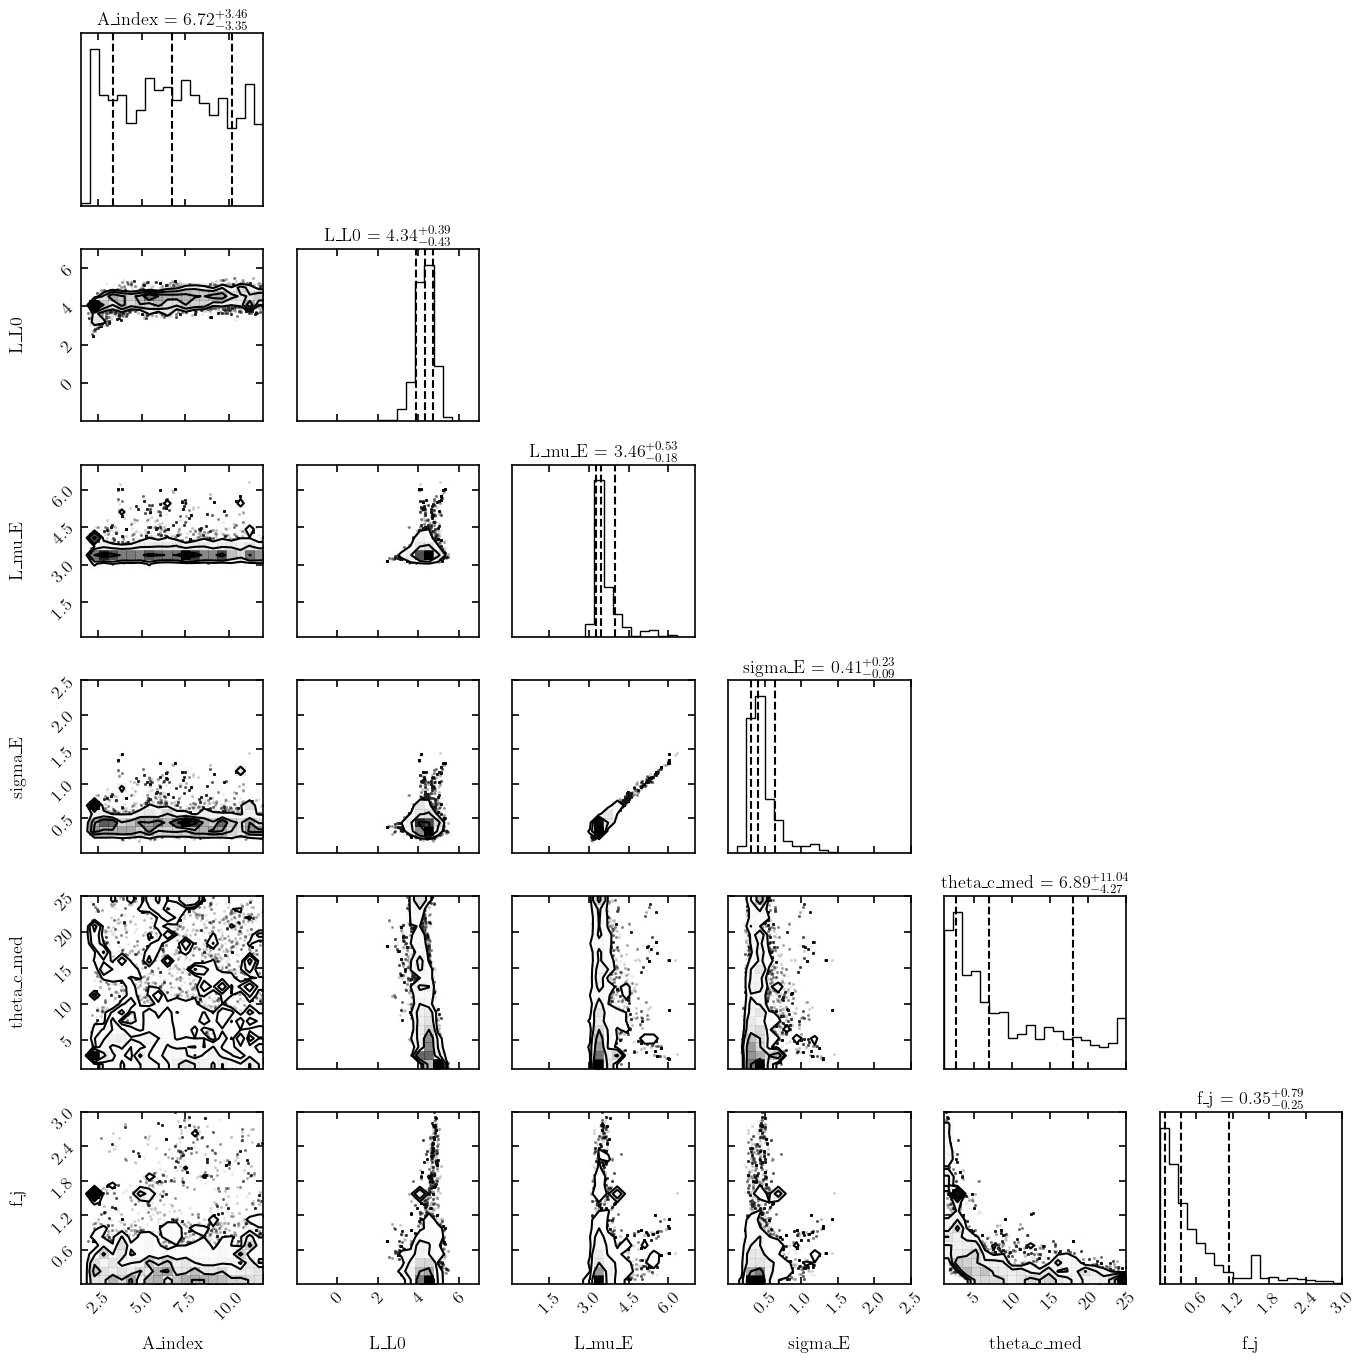

In [32]:
# Corner plot
backend = emcee.backends.HDFBackend(output_dir / 'emcee.h5')
discard = max(1000, backend.iteration // 3)
flat_samples = backend.get_chain(discard=discard, thin=15, flat=True)

plot_ranges = [
    [1.5, 12],
    [-2, 7],
    [0.1, 7],
    [0, 2.5],
    [1, 25],
    [0, 3],
]

figure = corner.corner(
    flat_samples,
    labels=PARAM_NAMES,
    show_titles=True,
    title_fmt='.2f',
    quantiles=[0.16, 0.5, 0.84],
    range=plot_ranges,
) 
plt.tight_layout()
plt.show()

In [33]:
# Baseline Run: No theta_c Scaling

In [34]:
# Baseline run: keep the same parameterization, but do not scale the luminosity by theta_c.

def simplified_montecarlo_lognormal_constant_eiso_no_theta(thetas, n_events, params_in, distances, k_interpolator, rng=None):
    A_index, L_L0, L_mu_E_10, sigma_E_10, theta_c_med, fj = thetas

    if rng is None:
        rng = params_in.rng

    l_10 = np.log(10)
    L_base_iso = luminosity_gen(A_index, n_events, rng=rng) * 10 ** (L_L0 + 49)
    L_obs_iso = L_base_iso

    E_p_rest = rng.lognormal(mean=L_mu_E_10 * l_10, sigma=sigma_E_10 * l_10, size=n_events)

    id_z = rng.integers(low=0, high=len(params_in.z_arr), size=n_events)
    z_arr = params_in.z_arr[id_z]
    d_L_sq = distances[id_z] ** 2
    E_p_obs = E_p_rest / (1 + z_arr)

    k_corr = k_interpolator.ev(np.log10(E_p_obs), z_arr)
    p_flux = L_obs_iso / (4 * np.pi * d_L_sq * k_corr) * 6.242e8

    return {
        'p_flux': p_flux,
        'E_p_obs': E_p_obs,
        'z_arr': z_arr,
        'L_base_iso': L_base_iso,
        'L_obs_iso': L_obs_iso,
        'theta_c_samples': np.full(n_events, theta_c_med),
        'lum_factor': np.ones(n_events),
    }


def log_likelihood_lognormal_constant_eiso_no_theta(thetas, params_in, distances, k_interpolator, n_events=10_000):
    theta_c_med, fj = thetas[4], thetas[5]

    gbm_eff = 0.6
    geometric_efficiency = float(geom_eff_interp(theta_c_med))
    epsilon = geometric_efficiency * fj

    expected_events = epsilon * len(params_in.z_arr) * gbm_eff * params_in.triggered_years
    if expected_events <= 0:
        return -inf, -inf, -inf, -inf, -inf

    results = simplified_montecarlo_lognormal_constant_eiso_no_theta(
        thetas, n_events, params_in, distances, k_interpolator
    )

    trigger_mask, analysis_mask = apply_detection_cuts(results['p_flux'], results['E_p_obs'])
    if np.sum(analysis_mask) <= 3:
        return -inf, -inf, -inf, -inf, -inf

    physics_efficiency = np.sum(trigger_mask) / n_events
    predicted_detections = expected_events * physics_efficiency
    observed_detections = params_in.yearly_rate * params_in.triggered_years

    l1 = score_func_cvm(results['p_flux'][analysis_mask], params_in.pflux_data, params_in.rng)
    l2 = score_func_cvm(results['E_p_obs'][analysis_mask], params_in.epeak_data, params_in.rng)
    l3 = poiss_log(k=observed_detections, mu=predicted_detections)

    return l1 + l2 + l3, l1, l2, l3, physics_efficiency


def initialize_walkers_lognormal_constant_eiso_no_theta(n_walkers):
    return initialize_walkers_lognormal_constant_eiso(n_walkers)


log_prob_no_theta = create_log_probability_function(
    log_prior_func=log_prior_lognormal_constant_eiso,
    log_likelihood_func=log_likelihood_lognormal_constant_eiso_no_theta,
    params_in=default_params,
    k_interpolator=k_interpolator,
)

output_dir_no_theta = src.init.create_run_dir(
    'Paper_Results/TopHat_LN_thetaDist_constantEiso_noThetaScale',
    use_timestamp=False,
)
filename_no_theta = output_dir_no_theta / 'emcee.h5'

initial_pos_no_theta, n_steps_to_do_no_theta, backend_no_theta = check_and_resume_mcmc(
    filename=filename_no_theta,
    n_steps=N_STEPS,
    initialize_walkers_func=initialize_walkers_lognormal_constant_eiso_no_theta,
    n_walkers=N_WALKERS,
)

if n_steps_to_do_no_theta > 0:
    sampler_no_theta = run_mcmc(
        log_probability_func=log_prob_no_theta,
        initial_walkers=initial_pos_no_theta,
        n_iterations=n_steps_to_do_no_theta,
        n_walkers=N_WALKERS,
        n_params=N_PARAMS,
        backend=backend_no_theta,
    )
else:
    print('Baseline run already complete at target steps.')


def summarize_chain(samples):
    q16, q50, q84 = np.percentile(samples, [16, 50, 84], axis=0)
    return q16, q50, q84

Loading existing directory  : Output_files/Paper_Results/TopHat_LN_thetaDist_constantEiso_noThetaScale
Continuing from iteration 20524


100%|██████████| 9476/9476 [10:20<00:00, 15.28it/s]


Posterior summary with theta_c scaling:
  A_index: 6.716 (+3.456, -3.348)
  L_L0: 4.335 (+0.393, -0.427)
  L_mu_E: 3.459 (+0.533, -0.178)
  sigma_E: 0.413 (+0.225, -0.092)
  theta_c_med: 6.887 (+11.040, -4.266)
  f_j: 0.345 (+0.794, -0.250)

Posterior summary without theta_c scaling:
  A_index: 6.616 (+3.572, -3.405)
  L_L0: 2.895 (+0.560, -0.451)
  L_mu_E: 3.440 (+0.500, -0.189)
  sigma_E: 0.406 (+0.190, -0.089)
  theta_c_med: 4.333 (+9.555, -2.651)
  f_j: 0.340 (+0.654, -0.242)


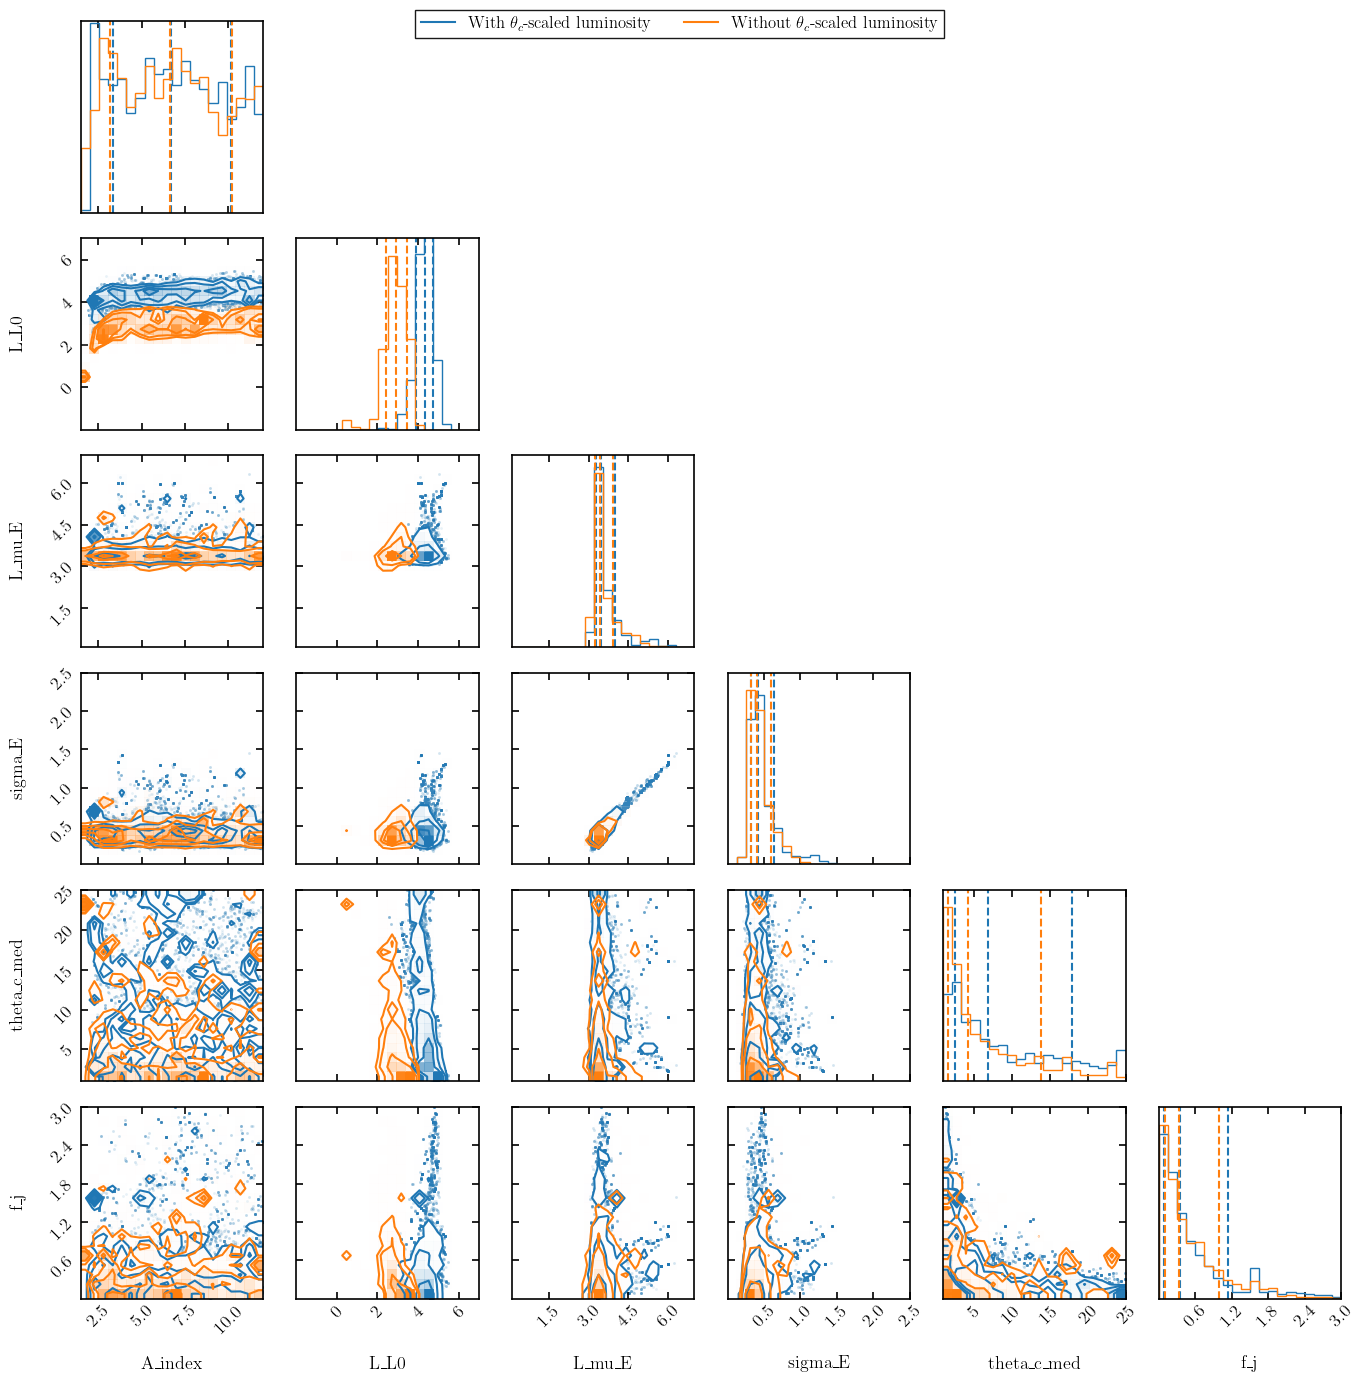

In [35]:
backend_theta = emcee.backends.HDFBackend(output_dir / 'emcee.h5')
backend_no_theta = emcee.backends.HDFBackend(output_dir_no_theta / 'emcee.h5')

discard_theta = max(1000, backend_theta.iteration // 3)
discard_no_theta = max(1000, backend_no_theta.iteration // 3)

flat_samples_theta = backend_theta.get_chain(discard=discard_theta, thin=15, flat=True)
flat_samples_no_theta = backend_no_theta.get_chain(discard=discard_no_theta, thin=15, flat=True)

q16_theta, q50_theta, q84_theta = summarize_chain(flat_samples_theta)
q16_no_theta, q50_no_theta, q84_no_theta = summarize_chain(flat_samples_no_theta)

print('Posterior summary with theta_c scaling:')
for name, median, lo, hi in zip(PARAM_NAMES, q50_theta, q16_theta, q84_theta):
    print(f'  {name}: {median:.3f} (+{hi - median:.3f}, -{median - lo:.3f})')

print('\nPosterior summary without theta_c scaling:')
for name, median, lo, hi in zip(PARAM_NAMES, q50_no_theta, q16_no_theta, q84_no_theta):
    print(f'  {name}: {median:.3f} (+{hi - median:.3f}, -{median - lo:.3f})')

plot_ranges = [
    [1.5, 12],
    [-2, 7],
    [0.1, 7],
    [0, 2.5],
    [1, 25],
    [0, 3],
]

figure = corner.corner(
    flat_samples_theta,
    labels=PARAM_NAMES,
    quantiles=[0.16, 0.5, 0.84],
    show_titles = False,
    range=plot_ranges,
    color='C0',
)
corner.corner(
    flat_samples_no_theta,
    fig=figure,
    labels=PARAM_NAMES,
    show_titles=False,
    quantiles=[0.16, 0.5, 0.84],
    range=plot_ranges,
    color='C1',
    plot_datapoints=False,
    fill_contours=False,
    plot_contours=True,
)

#add a legend
handle_1 = plt.Line2D([], [], color='C0', label='With $\\theta_c$-scaled luminosity')
handle_2 = plt.Line2D([], [], color='C1', label='Without $\\theta_c$-scaled luminosity')
figure.legend(
    handles=[handle_1, handle_2],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.0), # Adjusted to stay within figure bounds
    ncol=2,
    frameon=True,
    fontsize=12
)
figure.subplots_adjust(top=0.92)
figure.subplots_adjust(wspace=0.03, hspace=0.03)
plt.tight_layout()
plt.show()